<a href="https://colab.research.google.com/github/lynchpo/dragon_exploder_fred/blob/main/phase1_locked_walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 walkthrough — locked exogenous mortgage-rate model

**Repo:** `lynchpo/dragon_exploder_fred`  
**Task:** recover FRED macro signal for the weekly 30-year mortgage rate **without** using lagged mortgage rates.  
**Not the task:** beat a random walk at one-week-ahead persistence.

This notebook is the guided reproduction path. The long laboratory notebook documents exploration. **Do not retune here.** Candidate **C_fixed500** was locked from train-internal validation MSE (fixed 500 trees, no early stopping). The 2021–2026 hold-out is scored **once**.

Locked params: `learning_rate=0.05`, `max_depth=4`, `num_leaves=31`, `n_estimators=500`, `subsample=0.8`, `colsample_bytree=0.8`, `random_state=42`.

## 0. Setup

Run from the repo root, or add `src/` to `sys.path`. Install: `pip install -r requirements.txt`.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.stattools import durbin_watson

In [18]:
import os, sys
from pathlib import Path

REPO = Path("/content/dragon_exploder_fred")
if not (REPO / "src" / "phase1_locked_model.py").exists():
    !git clone https://github.com/lynchpo/dragon_exploder_fred.git /content/dragon_exploder_fred

%cd /content/dragon_exploder_fred
print("cwd:", Path.cwd())
print("lock file:", (Path.cwd() / "src" / "phase1_locked_model.py").exists())

/content/dragon_exploder_fred
cwd: /content/dragon_exploder_fred
lock file: True


## 1. Load FRED, align weekly, engineer exogenous features

Monthly series are forward-filled after they appear on the weekly Friday grid. Conservative rule: a monthly print is treated as available from the first weekly stamp at or after month-end. Revised FRED dates are not real-time vintages.

In [19]:
def fred_csv(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url, parse_dates=["observation_date"], index_col="observation_date")
    df.columns = [series_id]
    return df

ids = ["MORTGAGE30US", "DGS10", "FEDFUNDS", "UNRATE", "CPIAUCSL", "HOUST"]
raw = {s: fred_csv(s) for s in ids}
start = "2000-01-01"
parts = {
    "MORTGAGE30US": raw["MORTGAGE30US"][start:].resample("W-FRI").last(),
    "DGS10": raw["DGS10"][start:].resample("W-FRI").last(),
    "FEDFUNDS": raw["FEDFUNDS"][start:].resample("W-FRI").last().ffill(),
    "UNRATE": raw["UNRATE"][start:].resample("W-FRI").last().ffill(),
    "CPIAUCSL": raw["CPIAUCSL"][start:].resample("W-FRI").last().ffill(),
    "HOUST": raw["HOUST"][start:].resample("W-FRI").last().ffill(),
}
aligned = pd.concat(parts, axis=1).sort_index().loc[start:].copy()
aligned.columns = ids
print(aligned.shape, aligned.index.min().date(), "→", aligned.index.max().date())

(1391, 6) 2000-01-07 → 2026-08-28


In [20]:
import sys
from pathlib import Path

SRC = Path("/content/dragon_exploder_fred/src")
sys.path.insert(0, str(SRC))

from phase1_locked_model import (
    get_locked_params, load_feature_list, make_locked_lgbm, assert_exogenous,
)

print("ok", get_locked_params())

ok {'learning_rate': 0.05, 'max_depth': 4, 'num_leaves': 31, 'n_estimators': 500, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'verbosity': -1}


In [21]:
feat = aligned.copy()
feat["YIELD_SPREAD"] = feat["DGS10"] - feat["FEDFUNDS"]
for col in ["DGS10", "FEDFUNDS", "UNRATE", "CPIAUCSL", "HOUST", "YIELD_SPREAD"]:
    for L in [1, 2, 4, 8, 12]:
        feat[f"{col}_lag{L}"] = feat[col].shift(L)
for col in ["DGS10", "FEDFUNDS", "YIELD_SPREAD"]:
    feat[f"{col}_roll4_mean"] = feat[col].rolling(4).mean()
    feat[f"{col}_roll4_std"] = feat[col].rolling(4).std()
    feat[f"{col}_roll12_mean"] = feat[col].rolling(12).mean()
    feat[f"{col}_roll12_std"] = feat[col].rolling(12).std()
for col in ["DGS10", "FEDFUNDS"]:
    for w in [1, 2, 4, 8, 12]:
        feat[f"{col}_roc{w}"] = feat[col].pct_change(w)
feat["FEDFUNDS_change_12w"] = feat["FEDFUNDS"] - feat["FEDFUNDS"].shift(12)
feat["tightening_flag"] = (feat["FEDFUNDS_change_12w"] > 0.50).astype(float)
feat["DGS10_vol12"] = feat["DGS10"].rolling(12).std()
feat = feat.dropna().copy()

TARGET = "MORTGAGE30US"
features = [c for c in feat.columns if c != TARGET]
assert_exogenous(features)
print("Clean shape", feat.shape, "| predictors", len(features))
print(feat.index.min().date(), "→", feat.index.max().date())

STRESS_START, STRESS_END = "2022-01-01", "2023-12-31"

def shade(ax):
    ax.axvspan(
        pd.Timestamp(STRESS_START),
        pd.Timestamp(STRESS_END),
        color="#F6E58D",
        alpha=0.45,
        zorder=0,
    )

print(STRESS_START, "→", STRESS_END)

Clean shape (1371, 62) | predictors 61
2000-03-31 → 2026-07-03
2022-01-01 → 2023-12-31


## 2. Final-matrix EDA (Figures 1–5)

These plots use the **aligned / engineered** frame, not raw unaligned prints.

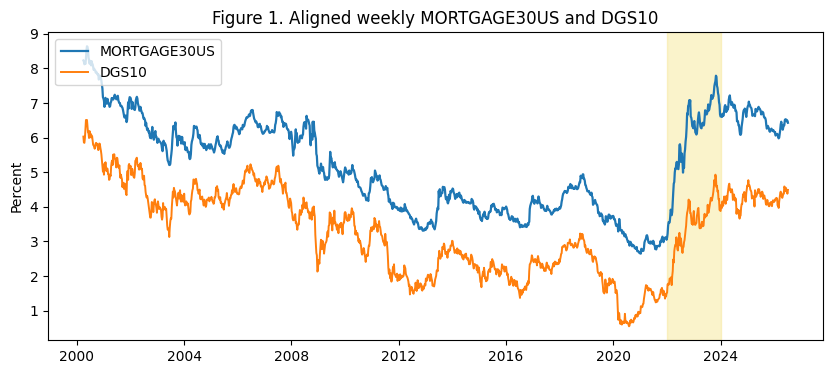

In [22]:
def shade(ax):
    ax.axvspan(pd.Timestamp(STRESS_START), pd.Timestamp(STRESS_END), color="#F6E58D", alpha=0.45, zorder=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(feat.index, feat["MORTGAGE30US"], label="MORTGAGE30US", lw=1.6)
ax.plot(feat.index, feat["DGS10"], label="DGS10", lw=1.4)
shade(ax)
ax.set_title("Figure 1. Aligned weekly MORTGAGE30US and DGS10")
ax.set_ylabel("Percent"); ax.legend(loc="upper left")
fig.savefig("fig1_aligned_levels.png"); plt.show()

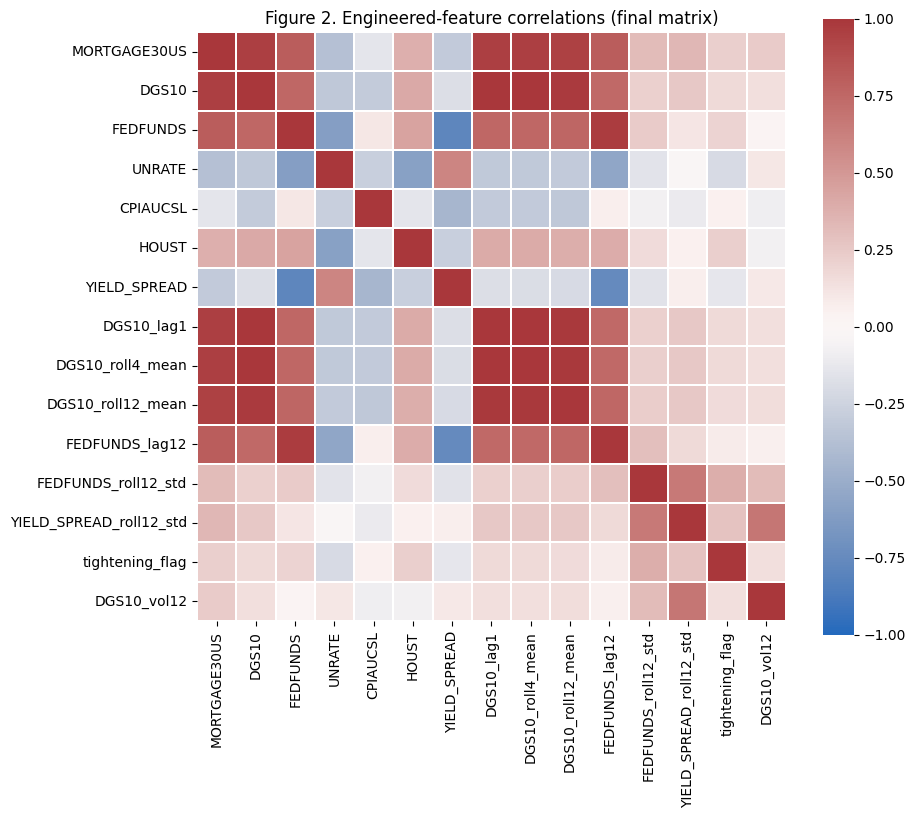

In [23]:
heat_cols = [c for c in [
    "MORTGAGE30US", "DGS10", "FEDFUNDS", "UNRATE", "CPIAUCSL", "HOUST", "YIELD_SPREAD",
    "DGS10_lag1", "DGS10_roll4_mean", "DGS10_roll12_mean",
    "FEDFUNDS_lag12", "FEDFUNDS_roll12_std", "YIELD_SPREAD_roll12_std",
    "tightening_flag", "DGS10_vol12",
] if c in feat.columns]
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(feat[heat_cols].corr(), ax=ax, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.3)
ax.set_title("Figure 2. Engineered-feature correlations (final matrix)")
fig.savefig("fig2_engineered_heatmap.png"); plt.show()

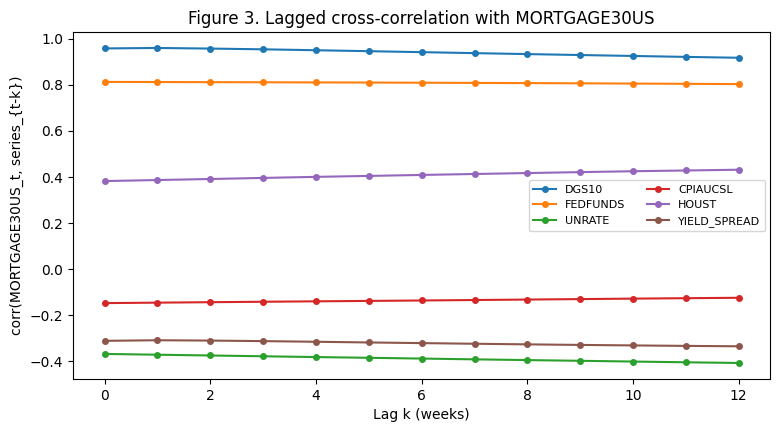

,DGS10,FEDFUNDS,UNRATE,CPIAUCSL,HOUST,YIELD_SPREAD
0,0.958,0.812,-0.369,-0.148,0.382,-0.312
1,0.960,0.812,-0.372,-0.146,0.386,-0.309
2,0.957,0.811,-0.376,-0.144,0.391,-0.311
3,0.954,0.811,-0.379,-0.142,0.396,-0.313
4,0.950,0.810,-0.382,-0.140,0.400,-0.316
5,0.946,0.810,-0.386,-0.139,0.404,-0.319
6,0.942,0.809,-0.389,-0.137,0.409,-0.322
7,0.937,0.808,-0.392,-0.135,0.413,-0.325
8,0.933,0.807,-0.396,-0.133,0.417,-0.327
9,0.929,0.806,-0.399,-0.131,0.421,-0.330


In [24]:
def lag_corr(y, x, max_lag=12):
    return pd.Series([y.corr(x.shift(k)) for k in range(max_lag + 1)])

y = feat[TARGET]
lag_vars = [c for c in ["DGS10", "FEDFUNDS", "UNRATE", "CPIAUCSL", "HOUST", "YIELD_SPREAD"] if c in feat.columns]
lag_df = pd.DataFrame({c: lag_corr(y, feat[c]) for c in lag_vars})
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in lag_df.columns:
    ax.plot(lag_df.index, lag_df[c], marker="o", ms=4, label=c)
ax.set_xlabel("Lag k (weeks)"); ax.set_ylabel("corr(MORTGAGE30US_t, series_{t-k})")
ax.set_title("Figure 3. Lagged cross-correlation with MORTGAGE30US")
ax.legend(ncol=2, fontsize=8)
fig.savefig("fig3_lagged_xcorr.png"); plt.show()
lag_df.round(3)

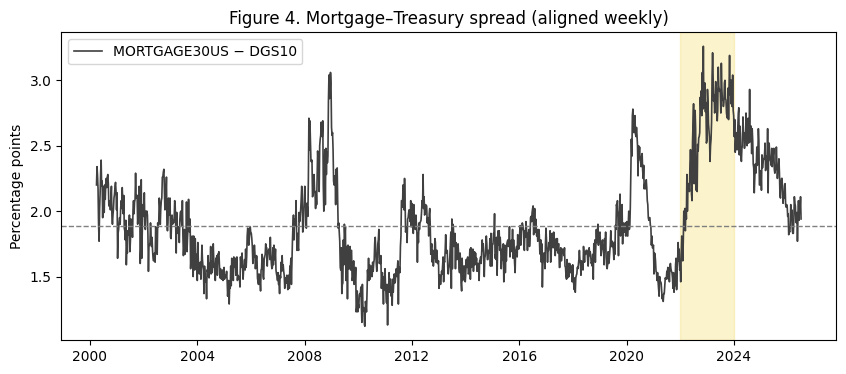

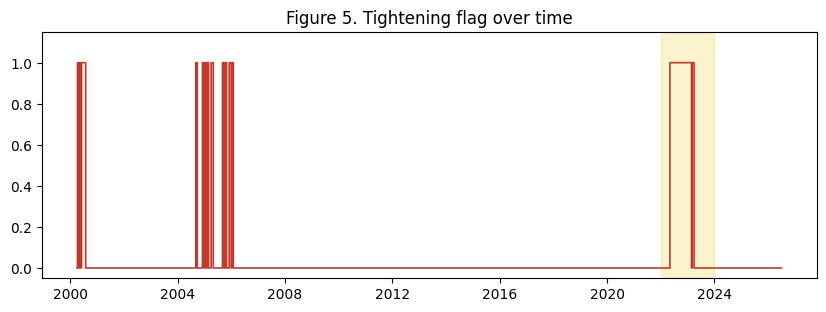

In [25]:
spread = feat["MORTGAGE30US"] - feat["DGS10"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(feat.index, spread, color="0.25", lw=1.2, label="MORTGAGE30US − DGS10")
shade(ax)
ax.axhline(spread.mean(), color="0.5", ls="--", lw=1)
ax.set_title("Figure 4. Mortgage–Treasury spread (aligned weekly)")
ax.set_ylabel("Percentage points"); ax.legend(loc="upper left")
fig.savefig("fig4_mortgage_treasury_spread.png"); plt.show()

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.step(feat.index, feat["tightening_flag"], where="post", color="#c0392b", lw=1.2)
shade(ax)
ax.set_ylim(-0.05, 1.15)
ax.set_title("Figure 5. Tightening flag over time")
fig.savefig("fig5_tightening_flag.png"); plt.show()

## 3. Chronological split

Report numbers used an 80/20 cut that landed near 2021-03-05 / 2021-03-12. New FRED rows can move that cut. If you need bit-for-bit report metrics, pin the dates below instead of a fractional cut.

In [26]:
PIN_DATES = True  # True = match the written report split
if PIN_DATES:
    train = feat.loc[: "2021-03-05"]
    test = feat.loc["2021-03-12":]
else:
    cut = int(len(feat) * 0.80)
    train, test = feat.iloc[:cut], feat.iloc[cut:]

y_tr, y_te = train[TARGET], test[TARGET]
X_tr, X_te = train[features], test[features]
mask_tt = (test.index >= STRESS_START) & (test.index <= STRESS_END)
print("Train", train.index.min().date(), "→", train.index.max().date(), len(train))
print("Test ", test.index.min().date(), "→", test.index.max().date(), len(test))

Train 2000-03-31 → 2021-03-05 1093
Test  2021-03-12 → 2026-07-03 278


## 4. Baselines (descriptive family comparison)

Random walk = best one-week-ahead persistence. Lasso = best linear exogenous model from the baseline week.

In [27]:
def metrics(name, y_true, y_pred):
    resid = y_true - y_pred
    row = {
        "Model": name,
        "Test MSE": round(mean_squared_error(y_true, y_pred), 3),
        "Test MAE": round(mean_absolute_error(y_true, y_pred), 3),
        "Test R²": round(r2_score(y_true, y_pred), 3),
        "Mean resid": round(float(resid.mean()), 3),
        "2022-23 mean resid": round(float(resid[mask_tt].mean()), 3) if mask_tt.any() else np.nan,
    }
    return row, resid

rows, preds = [], {}
rw = y_te.shift(1).copy(); rw.iloc[0] = y_tr.iloc[-1]
m, _ = metrics("1. Random walk", y_te, rw); rows.append(m); preds["RW"] = rw

sc = StandardScaler()
Xtr_s, Xte_s = sc.fit_transform(X_tr), sc.transform(X_te)
ols = LinearRegression().fit(Xtr_s, y_tr)
ols_pred = pd.Series(ols.predict(Xte_s), index=test.index)
m, r_ols = metrics("2. OLS", y_te, ols_pred); rows.append(m)

lasso = LassoCV(cv=5, max_iter=5000, random_state=42).fit(Xtr_s, y_tr)
lasso_pred = pd.Series(lasso.predict(Xte_s), index=test.index)
m, _ = metrics("3. LassoCV", y_te, lasso_pred); rows.append(m); preds["Lasso"] = lasso_pred

print(pd.DataFrame(rows).to_string(index=False))
print("OLS Durbin-Watson:", round(durbin_watson(r_ols.dropna()), 3))

         Model  Test MSE  Test MAE  Test R²  Mean resid  2022-23 mean resid
1. Random walk     0.014     0.085    0.993       0.012               0.034
        2. OLS     1.352     1.055    0.337       1.013               1.241
    3. LassoCV     1.191     0.996    0.415       0.932               1.197
OLS Durbin-Watson: 0.005


## 5. Locked LightGBM C (no search)

Winner was already chosen on train-internal validation MSE. This cell only **refits C on full train** and scores the sealed test once.

In [28]:
model_c = make_locked_lgbm()
model_c.fit(X_tr, y_tr)
pred_c = pd.Series(model_c.predict(X_te), index=test.index)
m_c, resid_c = metrics("C_fixed500 LightGBM", y_te, pred_c)
print(m_c)
print("Expect ~ Test R² 0.845, mean resid 0.40 if split is pinned and FRED vintage is close.")

{'Model': 'C_fixed500 LightGBM', 'Test MSE': 0.315, 'Test MAE': 0.471, 'Test R²': 0.845, 'Mean resid': 0.396, '2022-23 mean resid': 0.714}
Expect ~ Test R² 0.845, mean resid 0.40 if split is pinned and FRED vintage is close.


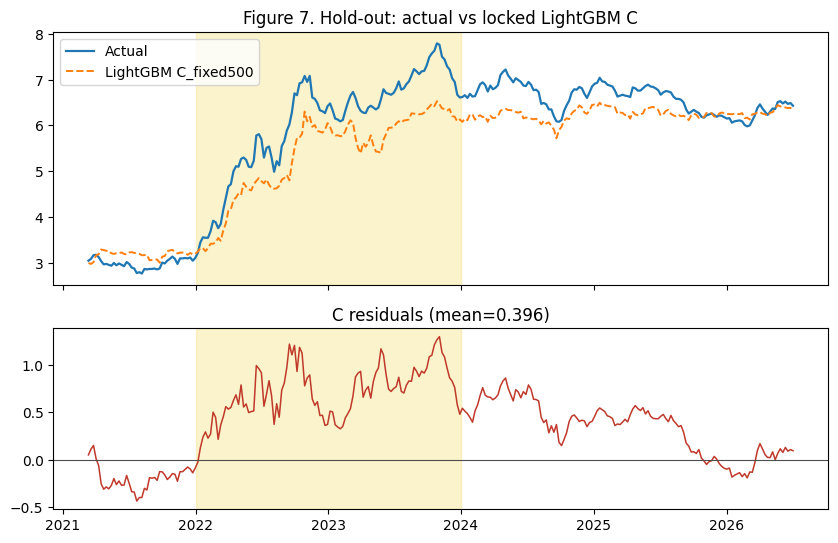

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True, gridspec_kw={"height_ratios": [1.4, 1]})
axes[0].plot(test.index, y_te, label="Actual", lw=1.6)
axes[0].plot(test.index, pred_c, label="LightGBM C_fixed500", lw=1.4, ls="--")
shade(axes[0])
axes[0].set_title("Figure 7. Hold-out: actual vs locked LightGBM C")
axes[0].legend(loc="upper left")
axes[1].plot(test.index, resid_c, color="#c0392b", lw=1.1)
axes[1].axhline(0, color="0.3", lw=0.8)
shade(axes[1])
axes[1].set_title(f"C residuals (mean={float(resid_c.mean()):.3f})")
fig.savefig("fig7_c_holdout_residuals.png"); plt.show()

## 6. Descriptive ladder (not selection)

Same locked hyperparameters; feature sets vary. Test metrics here do **not** choose the model.

            Model  Test MSE  Test MAE  Test R²  Mean resid  2022-23 mean resid
1_DGS10_lag1_only     0.555     0.668    0.728       0.537               0.878
  2_Treasury_core     0.430     0.589    0.789       0.496               0.692
 3_Full_exogenous     0.315     0.471    0.845       0.396               0.714


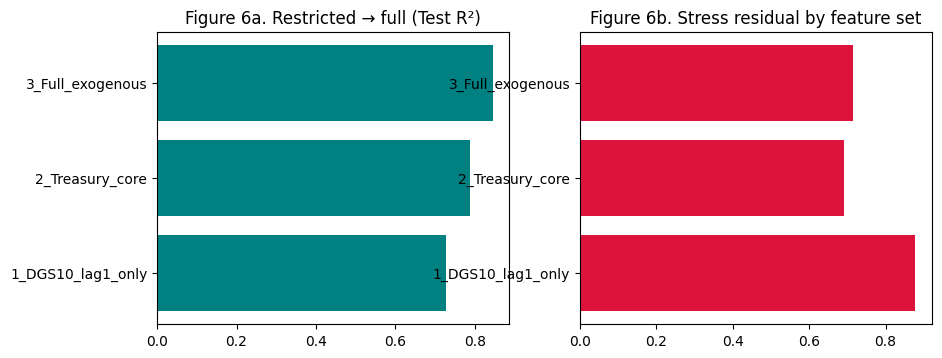

In [30]:
sets = {
    "1_DGS10_lag1_only": [c for c in ["DGS10_lag1"] if c in features],
    "2_Treasury_core": [c for c in [
        "DGS10", "DGS10_lag1", "DGS10_lag2", "DGS10_lag4",
        "DGS10_roll4_mean", "DGS10_roll12_mean", "DGS10_roll4_std", "DGS10_roll12_std",
        "YIELD_SPREAD", "YIELD_SPREAD_lag1", "DGS10_vol12",
    ] if c in features],
    "3_Full_exogenous": features,
}
ladder = []
for label, cols in sets.items():
    m = make_locked_lgbm()
    m.fit(X_tr[cols], y_tr)
    p = pd.Series(m.predict(X_te[cols]), index=test.index)
    row, _ = metrics(label, y_te, p)
    ladder.append(row)
ladder_df = pd.DataFrame(ladder)
print(ladder_df.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].barh(ladder_df["Model"], ladder_df["Test R²"], color="teal")
ax[0].set_title("Figure 6a. Restricted → full (Test R²)")
ax[1].barh(ladder_df["Model"], ladder_df["2022-23 mean resid"], color="crimson")
ax[1].set_title("Figure 6b. Stress residual by feature set")
fig.savefig("fig6_restricted_vs_full_ladder.png"); plt.show()

## 7. Interpretation guardrail

Under-prediction in 2022–2023 is consistent with a mortgage–Treasury relationship shift. It does not prove that mechanism or rule out omitted drivers (MBS demand, QT, origination capacity, credit premia).
**Phase 2** notebook link goes **here**